In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nancyrana3415688/zomato-data/Zomato-data-.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/nancyrana3415688/zomato-data/Zomato-data-.csv")

In [3]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [5]:
df.shape

(148, 7)

In [6]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [7]:
df['rate'].head()

0    4.1/5
1    4.1/5
2    3.8/5
3    3.7/5
4    3.8/5
Name: rate, dtype: object

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
def rateVal(val):
    val = val.split('/')
    val = val[0]
    return float(val)

df['rate'] = df['rate'].apply(rateVal)
print(df['rate'])

0      4.1
1      4.1
2      3.8
3      3.7
4      3.8
      ... 
143    3.3
144    3.3
145    4.0
146    3.0
147    3.9
Name: rate, Length: 148, dtype: float64


In [10]:
df['listed_in(type)'].unique()

array(['Buffet', 'Cafes', 'other', 'Dining'], dtype=object)

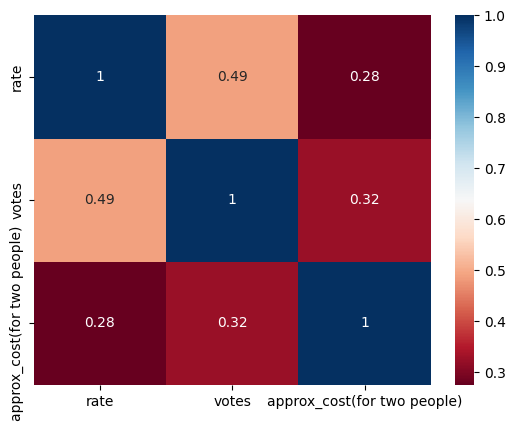

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cbar= True, cmap = 'RdBu')
plt.show()

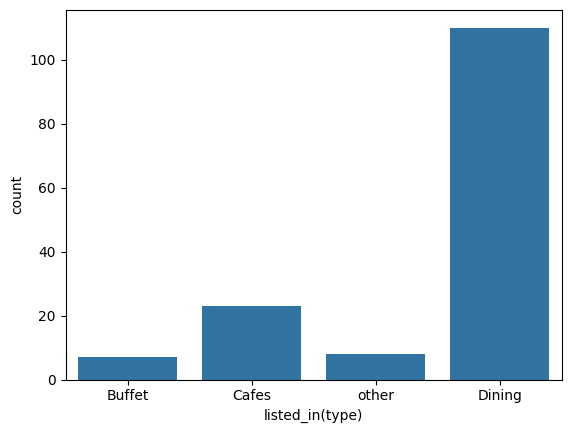

In [12]:
sns.countplot(x = df['listed_in(type)'])
plt.show()

In [13]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [14]:
df['name'].unique

<bound method Series.unique of 0                      Jalsa
1             Spice Elephant
2            San Churro Cafe
3      Addhuri Udupi Bhojana
4              Grand Village
               ...          
143         Melting Melodies
144          New Indraprasta
145             Anna Kuteera
146                   Darbar
147            Vijayalakshmi
Name: name, Length: 148, dtype: object>

<BarContainer object of 148 artists>

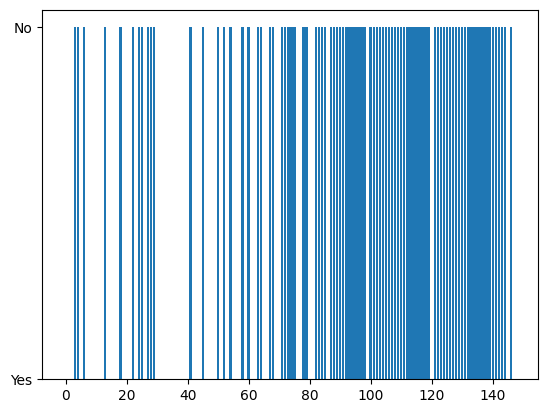

In [15]:
plt.bar(df.index, df['online_order'])

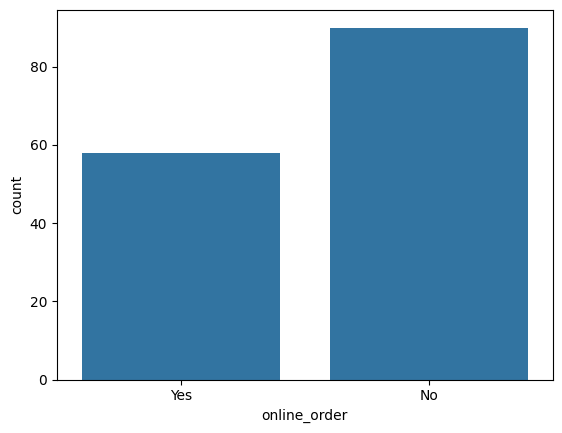

In [16]:
sns.countplot(x=df['online_order'])
plt.show()

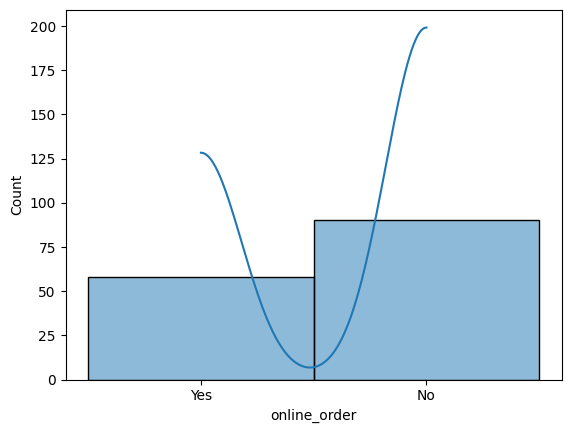

In [17]:
sns.histplot(df['online_order'], kde = True)
plt.show()

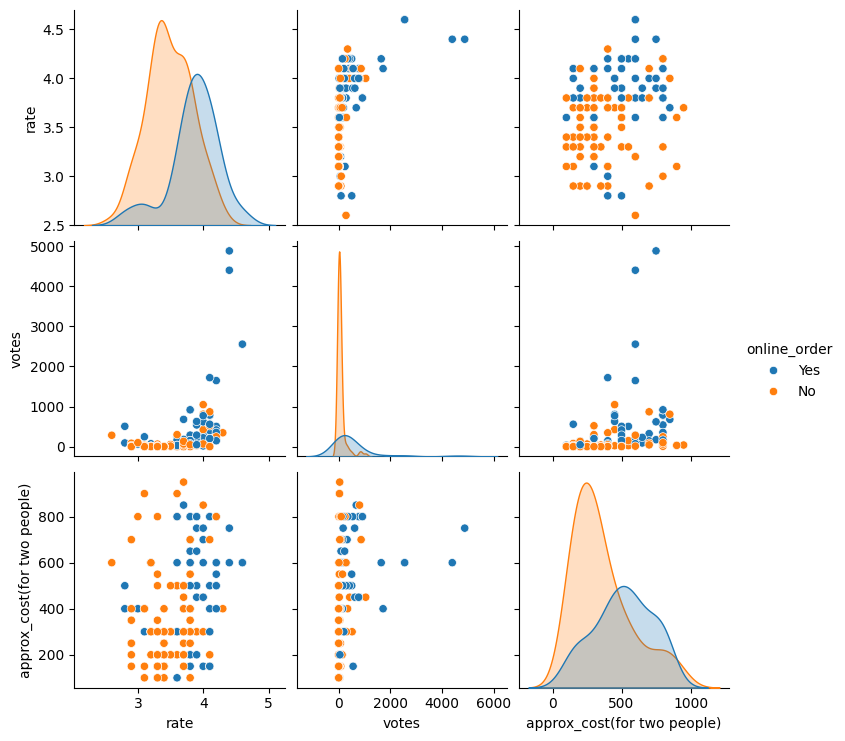

In [18]:
sns.pairplot(df, hue = 'online_order')
plt.show()

In [19]:
max_voted_rest = df['votes'].max()
max_voted_rest

4884

In [20]:
name = df.query("votes>4883" and "rate == 4.4")
name

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
38,Empire Restaurant,Yes,No,4.4,4884,750,other
86,Meghana Foods,Yes,No,4.4,4401,600,Dining


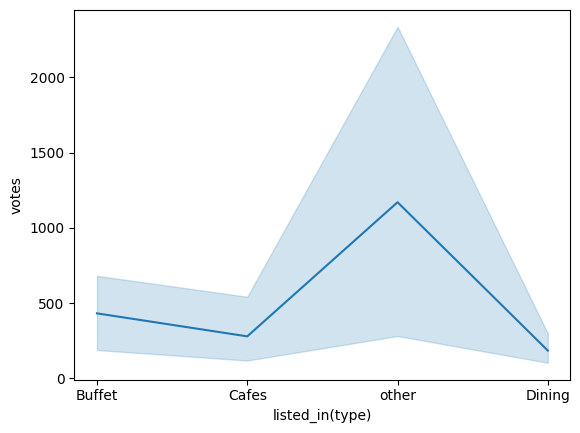

In [21]:
# sns.lineplot(x='listed_in(type)',y='votes',hue = 'votes', data = df)
# plt.show()

sns.lineplot(x='listed_in(type)', y='votes', data=df)
plt.show()

In [22]:
df['approx_cost(for two people)'].head()

0    800
1    800
2    800
3    300
4    600
Name: approx_cost(for two people), dtype: int64

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

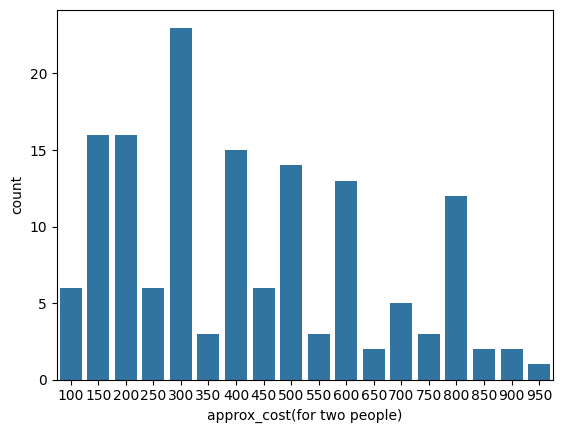

In [23]:
sns.countplot(x = df['approx_cost(for two people)'])

In [24]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [25]:
df.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


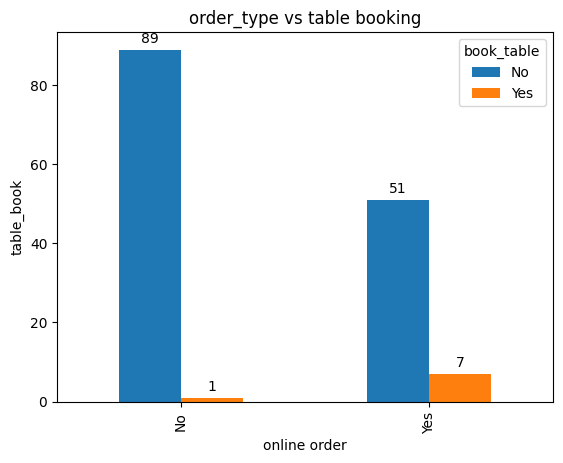

In [26]:
table = pd.crosstab(df["online_order"], df["book_table"])

# Plot
ax = table.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container, padding=3)


plt.title("order_type vs table booking")
plt.xlabel("online order")
plt.ylabel("table_book")
plt.show()

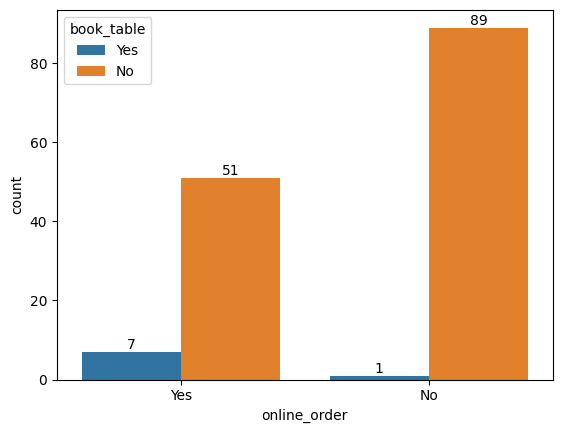

In [27]:
ax = sns.countplot(x = df['online_order'], hue = 'book_table', data =df)

for container in ax.containers:
    ax.bar_label(container)
plt.show()

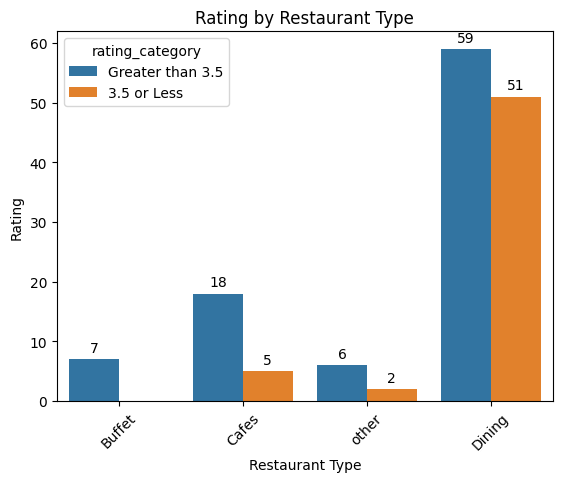

In [28]:
# ax = sns.barplot(data=df, x="listed_in(type)", y="rate")

# for container in ax.containers:
#     ax.bar_label(container, fmt="%.2f", padding=3)


df["rating_category"] = df["rate"].apply(
    lambda x: "Greater than 3.5" if x > 3.5 else "3.5 or Less"
)


ax = sns.countplot(
    data=df,
    x="listed_in(type)",
    hue="rating_category"
)

for con in ax.containers:
    ax.bar_label(con, padding=3)

plt.title("Rating by Restaurant Type")
plt.xlabel("Restaurant Type")
plt.ylabel("Rating")
plt.xticks(rotation=45)

plt.show()

In [29]:
# THANKYOU 